# Extensions

The notebook uses code from `\src`, which is separated into ``models`` and ``estimation``. 

Classes in ``models`` are defined to include the methods necessary to 
a. generate synthetic data of given model parameters
b. compute the log-likelihood of synthetic data
c. parameter unconstrain, constrain, and update functions for MCMC

Classes in ``estimation`` are defined to include the methods necessary to filter for latent state given observations and to estimate model parameters from observation data. Latent state filtering methods take in models with preset parameters and data, and return the filtered latent states. Parameter estimation methods take in the model and data, and return the estimated model parameters. MCMC methods return a chain of parameter estimates.

In [63]:
# Imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM, FixedAlphaSSM

# Filtering methods
from estimation.kalman_filter import KalmanFilter
from estimation.particle_filter import ParticleFilter

from estimation.resampling_methods import SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling 
# SystematicResampling will be the default for ParticleFilter

# Parameter Estimation methods
from estimation.mle_estimator import MLEEstimator
from estimation.nelder_mead import NelderMeadPMMLE
from estimation.metropolis_hastings import MetropolisHastings, BlockMetropolisHastings
from estimation.pmmh import PMMH, BlockPMMH

# Helpers
from estimation.kde import KDE
from utils import rmse, chain_ess, ess_trajectory

# Other state-space models
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Section I: Basic results (Filtering)
Quick review of basic results
1. Synthetic data generation using linear state-space model
2. Particle Filter and Kalman filter results under true parameters, RMSE, estimated log-likelihood (Particle filter) vs true log-likelihood (Kalman)

In [14]:
# true params
phi_true = 0.9
alpha_true = 1.5
sigma2_true = 0.25 # Parameterized using variance
tau2_true = 1.0 # Parameterized using variance

TRUE_PARAMS = {'phi': phi_true, 'alpha': alpha_true, 'sigma2': sigma2_true, 'tau2': tau2_true}

initial_var_fixed = 1.0

T = 200

SEED = 42

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma2=sigma2_true, tau2=tau2_true, initial_var = initial_var_fixed, seed= SEED) 
# Note that in the current implementation, when initial variance is provided, it is treated as an a priori hyperparameter and fixed throughout the simulation. It is not updated in parameter estimation
# If initial variance is not provided, the initial variance uses the default stationary distribution variance (sigma^2 / (1 - phi^2)), which is updated in parameter estimation.
print(model)

SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0)


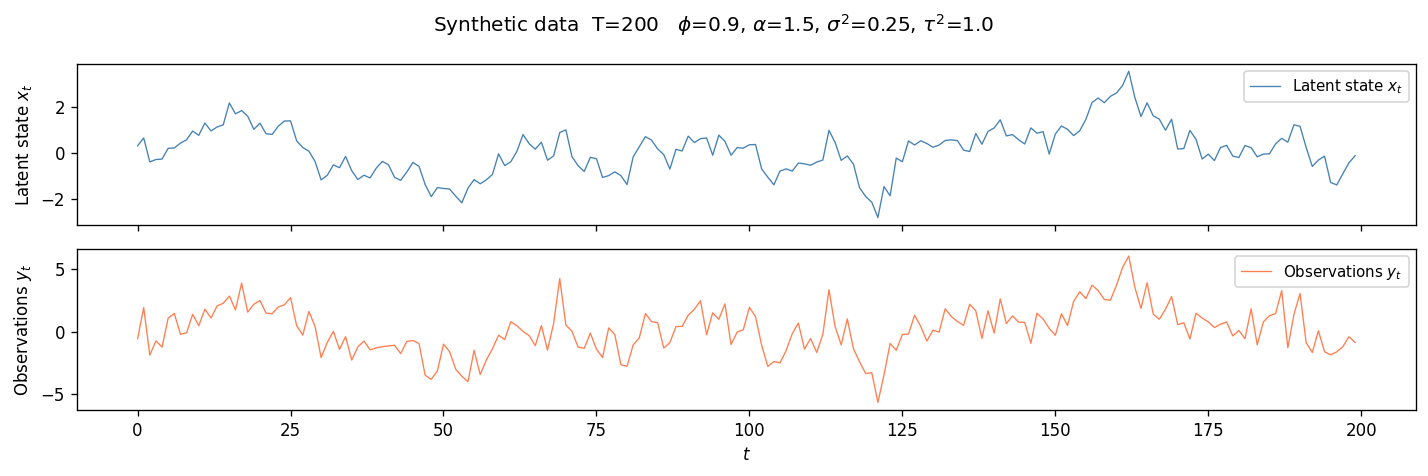

true_loglik = log p(y|x_true, theta) is the conditional log-likelihood given the known true state path: -267.41


In [15]:
# Generate Synthetic Data
states, observations, true_loglik = model.generate_data(T)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(states.ravel(), lw=0.8, color='steelblue', label='Latent state $x_t$')
axes[1].plot(observations.ravel(), lw=0.8, color='coral',     label='Observations $y_t$')
for ax in axes:
    ax.legend(fontsize=9)
    ax.set_ylabel(ax.get_legend().get_texts()[0].get_text())
axes[1].set_xlabel('$t$')
fig.suptitle(f'Synthetic data  T={T}   '
             rf'$\phi$={phi_true}, $\alpha$={alpha_true}, '
             rf'$\sigma^2$={sigma2_true}, $\tau^2$={tau2_true}')
plt.tight_layout()
plt.show()
print(f"true_loglik = log p(y|x_true, theta) is the conditional log-likelihood given the known true state path: {true_loglik:.2f}")


In [29]:
# Kalman filter (exact benchmark) — requires LinearGaussianSSM
kf_model = LinearGaussianSSM(
    a=np.array([[phi_true]]),
    c=np.array([[alpha_true]]),
    q=np.array([[sigma2_true]]),
    r=np.array([[tau2_true]]),
    p_0=np.array([[initial_var_fixed]])
)
kf = KalmanFilter(kf_model, observations)
kf_means, kf_covs, kf_loglik = kf.run_filter()
kf_states = kf_means.ravel()
kf_stds   = np.sqrt(kf_covs.ravel())

In [30]:
N_PARTICLES = 5000

# Particle filter
pf = ParticleFilter(model=model, N_particles=N_PARTICLES, data=observations,
                    resample_method=SystematicResampling(seed=SEED))
pf_states, p_his, w_his, rs_his, pf_loglik = pf.run_filter()
ess_traj = ess_trajectory(pf)

pf_states = pf_states.ravel()

In [31]:
kf_rmse = rmse(states.ravel(), kf_states)
pf_rmse = rmse(states.ravel(), pf_states)
print("True Log-likelihood log p(y | x_true, theta)")
print(f"Log-likelihood (true): {true_loglik:.2f}")
print()
print("Marginal Log-likelihoods log p(y | theta)")
print(f"Log-likelihood — KF (exact): {kf_loglik:.2f}")
print(f"Log-likelihood — PF estimate (N={N_PARTICLES}): {pf_loglik:.2f}")
print()
print(f"RMSE — KF: {kf_rmse:.4f}")
print(f"RMSE — PF: {pf_rmse:.4f}")

True Log-likelihood log p(y | x_true, theta)
Log-likelihood (true): -267.41

Marginal Log-likelihoods log p(y | theta)
Log-likelihood — KF (exact): -341.78
Log-likelihood — PF estimate (N=5000): -342.19

RMSE — KF: 0.4074
RMSE — PF: 0.4075


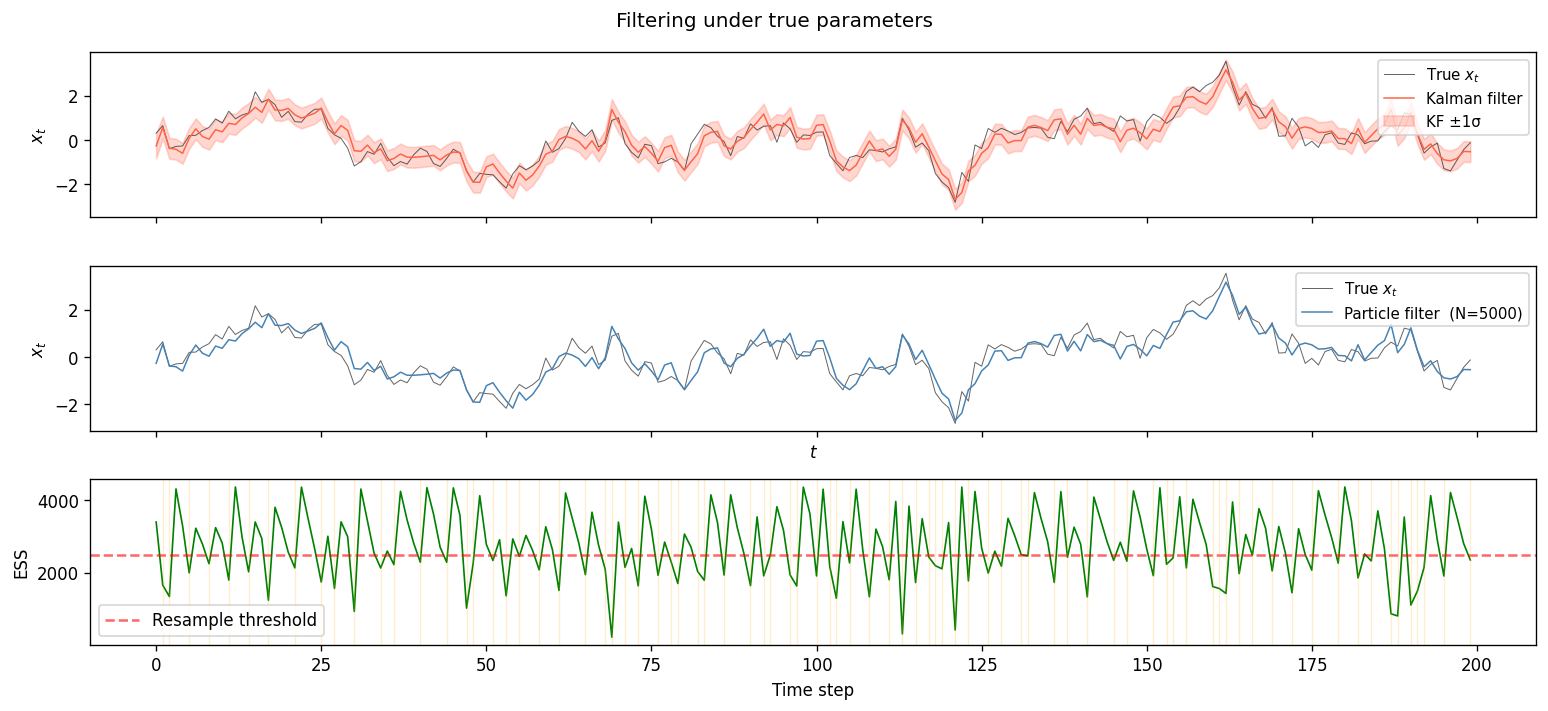

In [32]:
t_plot = np.arange(T)
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

for ax, est, label, color in [
    (axes[0], kf_states, 'Kalman filter', 'tomato'),
    (axes[1], pf_states, f'Particle filter  (N={N_PARTICLES})', 'steelblue'),
]:
    ax.plot(states.ravel(), lw=0.6, color='black', alpha=0.6, label='True $x_t$')
    ax.plot(est, lw=0.9, color=color, label=label)
    if color == 'tomato':                        # add KF ±1σ band
        ax.fill_between(t_plot, kf_states - kf_stds, kf_states + kf_stds,
                        alpha=0.25, color=color, label='KF ±1σ')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylabel('$x_t$')

axes[1].set_xlabel('$t$')
fig.suptitle('Filtering under true parameters')

axes[2].plot(ess_traj, color='green', lw=1)
axes[2].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rs_his) if r]:
    axes[2].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[2].set_ylabel('ESS')
axes[2].set_xlabel('Time step')
axes[2].legend()

plt.tight_layout()
plt.show()


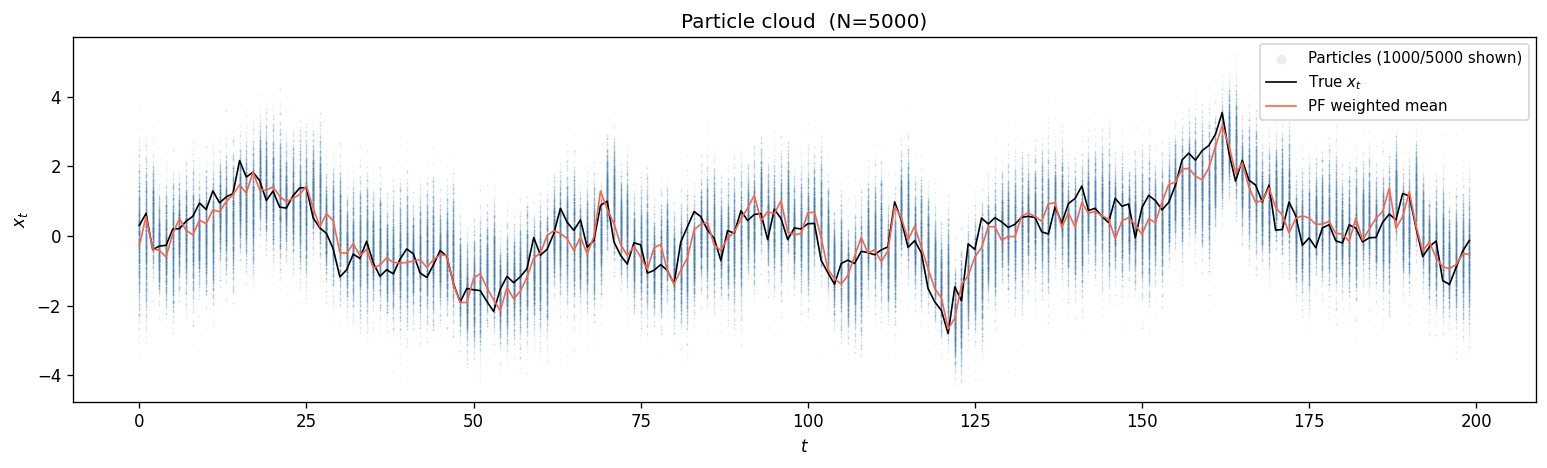

In [25]:
# Plot particle cloud (marginal filtering distribution at each timestep)
N_SHOW  = 1000   # particles sampled per timestep (out of N_PARTICLES)
rng_vis = np.random.default_rng(0)
t_plot  = np.arange(T)

t_scatter = np.repeat(t_plot, N_SHOW)
x_scatter = np.concatenate([
    p_his[t][rng_vis.choice(N_PARTICLES, N_SHOW, replace=False)]
    for t in t_plot
])

fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(t_scatter, x_scatter, s=1, alpha=0.12, color='steelblue',
           linewidths=0, label=f'Particles ({N_SHOW}/{N_PARTICLES} shown)')
ax.plot(states.ravel(), lw=1.0, color='black',  label='True $x_t$')
ax.plot(pf_states,      lw=1.0, color='tomato', label='PF weighted mean')
ax.set_xlabel('$t$')
ax.set_ylabel('$x_t$')
ax.legend(fontsize=9, loc='upper right', markerscale=6)
ax.set_title(f'Particle cloud  (N={N_PARTICLES})')
plt.tight_layout()
plt.show()

## Section II: Particle Filter More Detailed Results
Here, using true parameter values
1. Effect of number of particles on RMSE and log-likelihood estimation variability (Note: previous results showed that standard deviaition of log likelihood is proportional to 1/sqrt(N_particles))
2. Noise sensitivity: effect of σ and τ on filtering accuracy (RMSE of filtered latent state and estimated log-likelihood of observation given parameters), compared with Kalman filter (Note: previous notebook showed that Particle Filter and Kalman Filter reacted similarily to noise sensitivity)
3. Effect of Resampling Method Choice
4. Conclusion: optimal setup for Particle Filter (use in PMMH)

### 1. Effect of Number of Particles

Estimated runtime: 25 min

In [57]:
N_values = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
N_reps   = 30

rmse_by_N   = {n: [] for n in N_values}
loglik_by_N = {n: [] for n in N_values}

for N_p in N_values:
    for rep in range(N_reps):
        pf_n = ParticleFilter(model=model, N_particles=N_p, data=observations,
                              resample_method=SystematicResampling(seed=rep))
        pf_latent, _, _, _, ll_n = pf_n.run_filter()
        rmse_by_N[N_p].append(rmse(states.ravel(), pf_latent))
        loglik_by_N[N_p].append(ll_n)
    print(f"N={N_p:6d}  RMSE={np.mean(rmse_by_N[N_p]):.4f} ± {np.std(rmse_by_N[N_p]):.4f}"
          f"  loglik={np.mean(loglik_by_N[N_p]):.2f} ± {np.std(loglik_by_N[N_p]):.2f}")

N=    25  RMSE=0.4300 ± 0.0117  loglik=-345.51 ± 2.65
N=    50  RMSE=0.4200 ± 0.0071  loglik=-343.49 ± 2.23
N=   100  RMSE=0.4132 ± 0.0055  loglik=-342.82 ± 1.53
N=   250  RMSE=0.4094 ± 0.0039  loglik=-342.23 ± 1.01
N=   500  RMSE=0.4087 ± 0.0027  loglik=-342.05 ± 0.81
N=  1000  RMSE=0.4074 ± 0.0018  loglik=-341.91 ± 0.45
N=  2500  RMSE=0.4078 ± 0.0011  loglik=-341.85 ± 0.26
N=  5000  RMSE=0.4075 ± 0.0009  loglik=-341.88 ± 0.13
N= 10000  RMSE=0.4076 ± 0.0005  loglik=-341.86 ± 0.15
N= 20000  RMSE=0.4074 ± 0.0003  loglik=-341.82 ± 0.11


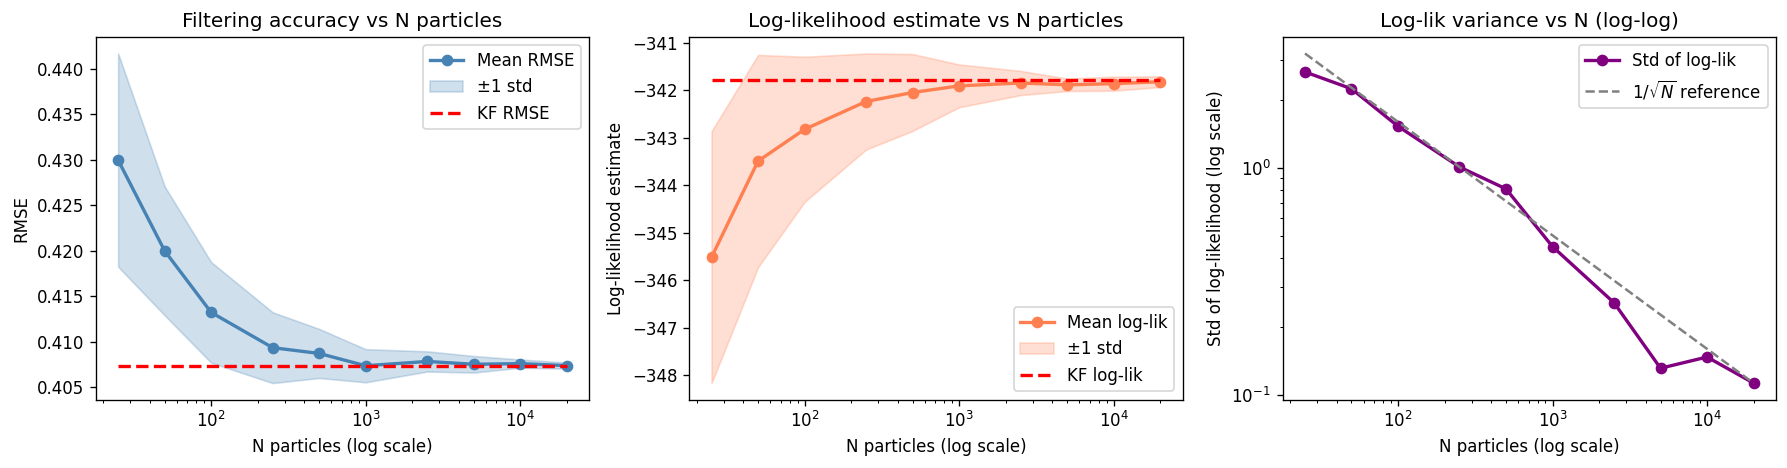

In [64]:
# Reference RMSE and log likelihood from Kalman Filter are stored in kf_rmse and kf_loglik
rmse_mean   = np.array([np.mean(rmse_by_N[n]) for n in N_values])
rmse_std    = np.array([np.std(rmse_by_N[n]) for n in N_values])
loglik_mean = np.array([np.mean(loglik_by_N[n]) for n in N_values])
loglik_std  = np.array([np.std(loglik_by_N[n]) for n in N_values])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── RMSE mean ± 1 std ──────────────────────────────────────────────────────
axes[0].semilogx(N_values, rmse_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(N_values, rmse_mean - rmse_std, rmse_mean + rmse_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].semilogx(N_values, kf_rmse * np.ones(len(N_values)), '--', color = 'red', lw=2, label = 'KF RMSE')
axes[0].set_xlabel('N particles (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Filtering accuracy vs N particles')
axes[0].legend()

# ── log-likelihood mean ± 1 std ────────────────────────────────────────────
axes[1].semilogx(N_values, loglik_mean, 'o-', color='coral', lw=2, label='Mean log-lik')
axes[1].fill_between(N_values, loglik_mean - loglik_std, loglik_mean + loglik_std,
                     alpha=0.25, color='coral', label='±1 std')
# plot true log-likelihood of data as a constant line
axes[1].semilogx(N_values, kf_loglik * np.ones(len(N_values)), '--', color='red', lw=2, label='KF log-lik')
axes[1].set_xlabel('N particles (log scale)')
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood estimate vs N particles')
axes[1].legend()

# ── log-likelihood std on log-log (should scale as 1/sqrt(N)) ─────────────
axes[2].loglog(N_values, loglik_std, 'o-', color='purple', lw=2, label='Std of log-lik')
# reference 1/sqrt(N) line anchored at the largest N
ref_scale = loglik_std[-1] * np.sqrt(N_values[-1])
ref_line  = ref_scale / np.sqrt(N_values)
axes[2].loglog(N_values, ref_line, '--', color='gray', lw=1.5, label='$1/\\sqrt{N}$ reference')
axes[2].set_xlabel('N particles (log scale)')
axes[2].set_ylabel('Std of log-likelihood (log scale)')
axes[2].set_title('Log-lik variance vs N (log-log)')
axes[2].legend()

plt.tight_layout()
plt.show()

We see that RMSE and log-likelihood from Particle Filter estimates converge to Kalman Filter values as $N \to \infty$. The standard deviation of PF log-likelihood estimate is proportional to $1/\sqrt{N}$, as expected.

### 2. Noise Sensitivity

In [ ]:
# Sweep σ so r = σ²/τ² ∈ [0.01, 9]; repeat for several τ values and plot as separate lines.
phi_r    = 0.9
alpha_r  = 1.0
N_r      = 500 # Number of particles
T_r      = 200
n_reps_r = 20  # Number of repeated trials for data generation and filtering

tau_r_vals   = [0.5, 1.0, 2.0, 4.0]
sigma_r_vals = np.logspace(-1, np.log10(3.0), 22)   # sigma 0.1 … 3.0

results_by_tau = {}
rng_r = np.random.default_rng(77)

for tau_r in tau_r_vals:
    ratio_vals       = sigma_r_vals ** 2 / tau_r ** 2
    pf_rmse_mean     = np.zeros(len(sigma_r_vals))
    pf_rmse_std      = np.zeros(len(sigma_r_vals))
    kf_rmse_mean     = np.zeros(len(sigma_r_vals))
    pf_loglik_mean   = np.zeros(len(sigma_r_vals))
    pf_loglik_std    = np.zeros(len(sigma_r_vals))
    kf_loglik_mean   = np.zeros(len(sigma_r_vals))
    loglik_bias_mean = np.zeros(len(sigma_r_vals))
    loglik_bias_std  = np.zeros(len(sigma_r_vals))

    for i, sigma_r in enumerate(sigma_r_vals):
        pf_rmse_i   = []
        kf_rmse_i   = []
        pf_loglik_i = []
        kf_loglik_i = []

        for rep in range(n_reps_r):
            seed_r = int(rng_r.integers(0, 10**6))
            m_r = SimpleLinearGaussianSSM(phi=phi_r, alpha=alpha_r,
                                          sigma2=sigma_r**2, tau2=tau_r**2,
                                          initial_var=initial_var_fixed, seed=seed_r)
            s_r, o_r, _ = m_r.generate_data(T_r)
            obs_r  = o_r[:, 0]
            true_r = s_r[:, 0]

            pf_r = ParticleFilter(model=m_r, N_particles=N_r, data=obs_r,
                                  resample_method=SystematicResampling(seed=rep))
            pf_r_latent, _, _, _, pf_r_loglik = pf_r.run_filter()
            pf_rmse_i.append(rmse(true_r, pf_r_latent))
            pf_loglik_i.append(pf_r_loglik)

            kf_m = LinearGaussianSSM(
                a=np.array([[phi_r]]),
                c=np.array([[alpha_r]]),
                q=np.array([[sigma_r ** 2]]),
                r=np.array([[tau_r ** 2]]),
                p_0=np.array([[initial_var_fixed]])
            )
            kf_r = KalmanFilter(model=kf_m, data=obs_r)
            filt_m, _, kf_r_loglik = kf_r.run_filter()
            kf_rmse_i.append(rmse(true_r, filt_m[:, 0]))
            kf_loglik_i.append(kf_r_loglik)

        bias_i = [p - k for p, k in zip(pf_loglik_i, kf_loglik_i)]

        pf_rmse_mean[i]     = np.mean(pf_rmse_i)
        pf_rmse_std[i]      = np.std(pf_rmse_i)
        kf_rmse_mean[i]     = np.mean(kf_rmse_i)
        pf_loglik_mean[i]   = np.mean(pf_loglik_i)
        pf_loglik_std[i]    = np.std(pf_loglik_i)
        kf_loglik_mean[i]   = np.mean(kf_loglik_i)
        loglik_bias_mean[i] = np.mean(bias_i)
        loglik_bias_std[i]  = np.std(bias_i)

    results_by_tau[tau_r] = dict(
        ratio=ratio_vals,
        pf_rmse_mean=pf_rmse_mean,
        pf_rmse_std=pf_rmse_std,
        kf_rmse_mean=kf_rmse_mean,
        pf_loglik_mean=pf_loglik_mean,
        pf_loglik_std=pf_loglik_std,
        kf_loglik_mean=kf_loglik_mean,
        loglik_bias_mean=loglik_bias_mean,
        loglik_bias_std=loglik_bias_std,
    )
    print(f"\u03c4\u00b2={tau_r**2:.2f}  done")


τ²=0.25  done


In [ ]:
# Print report: log-likelihood bias (PF − KF) across noise regimes
print(f"Log-likelihood bias  E[PF − KF]   N_particles={N_r}, T={T_r}, reps={n_reps_r}\n")
step = max(1, len(sigma_r_vals) // 8)

for tau_r in tau_r_vals:
    r = results_by_tau[tau_r]
    print(f"\u03c4\u00b2 = {tau_r**2:.2f}")
    print(f"  {'\u03c3\u00b2/\u03c4\u00b2':>8}  {'KF loglik':>10}  {'PF loglik':>10}  {'Bias':>8}  {'PF std':>7}")
    print(f"  {'-' * 50}")
    for j in range(0, len(r['ratio']), step):
        print(f"  {r['ratio'][j]:8.3f}  {r['kf_loglik_mean'][j]:10.2f}  "
              f"{r['pf_loglik_mean'][j]:10.2f}  {r['loglik_bias_mean'][j]:8.2f}  "
              f"{r['pf_loglik_std'][j]:7.2f}")
    print()


In [ ]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(tau_r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tau_r, col in zip(tau_r_vals, colors):
    r = results_by_tau[tau_r]
    lbl = f'\u03c4\u00b2={tau_r**2:.2f}'

    # Bias (mean ± 1 std)
    axes[0].semilogx(r['ratio'], r['loglik_bias_mean'], 'o-', color=col, lw=1.5, label=lbl)
    axes[0].fill_between(r['ratio'],
                         r['loglik_bias_mean'] - r['loglik_bias_std'],
                         r['loglik_bias_mean'] + r['loglik_bias_std'],
                         alpha=0.15, color=col)

    # PF log-lik std
    axes[1].semilogx(r['ratio'], r['pf_loglik_std'], 'o-', color=col, lw=1.5, label=lbl)

axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('\u03c3\u00b2/\u03c4\u00b2  (signal-to-noise ratio, log scale)')
axes[0].set_ylabel('E[PF log-lik \u2212 KF log-lik]')
axes[0].set_title(f'Log-likelihood bias  (N={N_r})')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('\u03c3\u00b2/\u03c4\u00b2  (log scale)')
axes[1].set_ylabel('Std of PF log-lik estimate')
axes[1].set_title(f'PF log-likelihood variability  (N={N_r})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sigma_vals, sigma_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(sigma_vals, sigma_mean - sigma_std, sigma_mean + sigma_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('Process noise σ')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Process noise vs filtering accuracy')
axes[0].legend()

axes[1].plot(tau_vals, tau_mean, 'o-', color='coral', lw=2, label='Mean RMSE')
axes[1].fill_between(tau_vals, tau_mean - tau_std, tau_mean + tau_std,
                     alpha=0.25, color='coral', label='±1 std')
axes[1].set_xlabel('Observation noise τ')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Observation noise vs filtering accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3. Effect of Resampling Method Choice

In [ ]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = T
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, initial_var = initial_var_fixed, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        _, ph_, wh_, _, ll = pf_.run_filter(verbose=False)
        rmse_rs[name].append(rmse(s[:, 0], filtered_trajectory(pf_)))
        loglik_rs[name].append(ll)

In [ ]:
results = {
    name: (np.mean(rmse_rs[name]), np.std(rmse_rs[name]),
           np.mean(loglik_rs[name]), np.std(loglik_rs[name]))
    for name in resamplers
}

best = {
    0: min(results, key=lambda x: results[x][0]),  # lowest RMSE mean
    1: min(results, key=lambda x: results[x][1]),  # lowest RMSE std
    2: max(results, key=lambda x: results[x][2]),  # highest loglik mean
    3: min(results, key=lambda x: results[x][3]),  # lowest loglik std
}

def star(name, col):
    return '★' if best[col] == name else ' '

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print('-' * 60)
for name, (rm, rs, lm, ls) in results.items():
    print(f"{name:<12}  {rm:>9.4f}{star(name,0)}  {rs:>8.4f}{star(name,1)}  "
          f"{lm:>11.2f}{star(name,2)}  {ls:>9.2f}{star(name,3)}")

In [ ]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

### 4. Conclusion

Choose `Systematicmpling` or `StratifiedResampling` as resampling method. For current synthetic data, around N_particles = 1000 should be sufficient.

## Section III. Basic Results (Estimation)
1. Parameter Log-Likelihood Ridge for (alpha, sigma2) with other parameters fixed to true values, plot log-likelihood surface
2. Parameter estimation using MLE (alpha fixed at true alpha)
3. Parameter estimation using MH (alpha fixed at true alpha)
4. Parameter estimation using Nelder-Mead and particle filter likelihood estimate
5. Comparison table summary of parameter estimation methods
6. (Optional) Plot individual scatterplot of estimated parameters (in pairs) on log-likelihood surfaces for parameter estimation (with other parameters fixed to true value)


### 1. Examining Log-Likelihood Surface and Scale Ambiguity

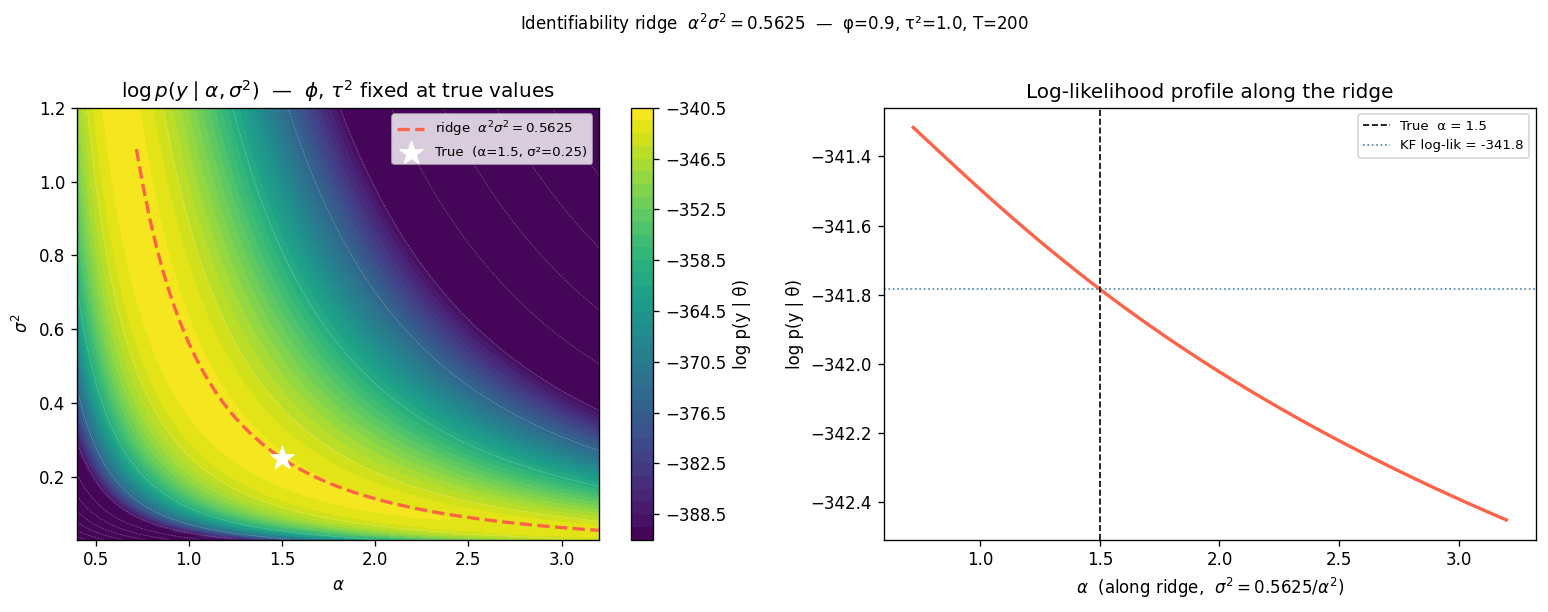

In [58]:
# Log-Likelihood Ridge Plot
# 2D slice of log p(y | alpha, sigma2) with phi and tau2 fixed at true values.
# The ridge lies along alpha^2 * sigma2 = alpha_true^2 * sigma2_true (scale ambiguity).

obs_1d = observations.ravel()

alpha_grid  = np.linspace(0.4, 3.2, 80)
sigma2_grid = np.linspace(0.03, 1.2, 80)

LL = np.full((len(sigma2_grid), len(alpha_grid)), np.nan)
for j, a in enumerate(alpha_grid):
    for i, s2 in enumerate(sigma2_grid):
        try:
            model.update_params([phi_true, a, s2, tau2_true])
            LL[i, j] = model.log_likelihood(obs_1d)
        except Exception:
            pass
model.update_params([phi_true, alpha_true, sigma2_true, tau2_true])  # restore

# Ridge curve: alpha^2 * sigma2 = C (scale-ambiguity constraint)
C_ridge      = alpha_true**2 * sigma2_true        # = 1.5^2 * 0.25 = 0.5625
ridge_sigma2 = C_ridge / alpha_grid**2
ridge_mask   = (ridge_sigma2 >= sigma2_grid.min()) & (ridge_sigma2 <= sigma2_grid.max())

# Log-likelihood evaluated exactly along the ridge
ridge_ll = []
for a in alpha_grid:
    s2 = C_ridge / a**2
    if s2 < sigma2_grid.min() or s2 > sigma2_grid.max():
        ridge_ll.append(np.nan)
        continue
    try:
        model.update_params([phi_true, a, s2, tau2_true])
        ridge_ll.append(model.log_likelihood(obs_1d))
    except Exception:
        ridge_ll.append(np.nan)
model.update_params([phi_true, alpha_true, sigma2_true, tau2_true])  # restore
ridge_ll = np.array(ridge_ll)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: filled contour heatmap ──────────────────────────────────────────
vmax = np.nanmax(LL)
vmin = vmax - 50
im = axes[0].contourf(alpha_grid, sigma2_grid, np.clip(LL, vmin, vmax),
                      levels=40, cmap='viridis')
axes[0].contour(alpha_grid, sigma2_grid, LL, levels=12,
                colors='white', linewidths=0.35, alpha=0.35)
fig.colorbar(im, ax=axes[0], label='log p(y | θ)')
axes[0].plot(alpha_grid[ridge_mask], ridge_sigma2[ridge_mask],
             '--', color='tomato', lw=2,
             label=r'ridge  $\alpha^2 \sigma^2 = %.4f$' % C_ridge)
axes[0].scatter([alpha_true], [sigma2_true],
                color='white', marker='*', s=200, zorder=5,
                label=f'True  (α={alpha_true}, σ²={sigma2_true})')
axes[0].set_xlabel(r'$\alpha$')
axes[0].set_ylabel(r'$\sigma^2$')
axes[0].set_title(r'$\log p(y \mid \alpha, \sigma^2)$  —  $\phi$, $\tau^2$ fixed at true values')
axes[0].legend(fontsize=8, loc='upper right')

# ── right: 1-D profile along the ridge ───────────────────────────────────
axes[1].plot(alpha_grid, ridge_ll, color='tomato', lw=2)
axes[1].axvline(alpha_true, ls='--', color='black', lw=1,
                label=f'True  α = {alpha_true}')
axes[1].axhline(kf_loglik, ls=':', color='steelblue', lw=1,
                label=f'KF log-lik = {kf_loglik:.1f}')
axes[1].set_xlabel(r'$\alpha$  (along ridge,  $\sigma^2 = {%.4f}/\alpha^2$)' % C_ridge)
axes[1].set_ylabel('log p(y | θ)')
axes[1].set_title('Log-likelihood profile along the ridge')
axes[1].legend(fontsize=8)

plt.suptitle(
    rf'Identifiability ridge  $\alpha^2 \sigma^2 = {C_ridge:.4f}$'
    rf'  —  φ={phi_true}, τ²={tau2_true}, T={T}',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()


### 2.Parameter Estimation with MLE

In [59]:
# MLE with alpha fixed — 3-param model: (phi, sigma2, tau2)
# Uses the exact Kalman log-likelihood, so results are deterministic.

model_mle = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

mle = MLEEstimator(
    model=model_mle, # Calls model_mle.log_likelihood() which uses Kalman filter internally
    data=observations,
    method='L-BFGS-B',
    n_restarts=3,
    restart_std=0.5,
    seed=0,
)
mle_result = mle.fit()
mle.compute_std_errors()
print(mle_result.summary())


Restart 0/3 best val: 341.277620077348
Restart 1/3 best val: 341.277620077348
Restart 2/3 best val: 341.277620077348
MLEEstimator.fit  0.089s
MLEResult  loglik=-341.2776  converged  n_evals=64
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.885722      0.046616
  sigma2                0.250958      0.086108
  tau2                  0.865117      0.180643


### 3. Parameter Estimation with Metropolis-Hastings

In [44]:
# Fixing alpha breaks the alpha·sqrt(sigma2) ridge and makes the posterior
# identifiable.  Parameters are now (phi, sigma2, tau2) with variance params.

def log_prior_fixed_alpha(theta_con):
    """Independent priors on (phi, sigma2, tau2) with alpha fixed."""
    phi, sigma2, tau2 = theta_con
    if phi <= -1 or phi >= 1:
        return -np.inf
    if sigma2 <= 0 or tau2 <= 0:
        return -np.inf
    return sum([
        np.log(2) - np.log(1 + phi ** 2),     # Cauchy(0,1) on (-1,1) for phi
        -np.log(sigma2),                      # HalfCauchy(0,1) ∝ 1/sigma2
        -np.log(tau2),                        # HalfCauchy(0,1) ∝ 1/tau2
    ])


N_ITER_FA  = 3000
BURN_IN_FA = 500

model_fa  = FixedAlphaSSM(alpha_fixed = alpha_true, phi = phi_true, sigma2 = sigma2_true, tau2 = tau2_true, initial_var = initial_var_fixed, seed=5)
theta0_fa = model_fa.unconstrain_params(
    [phi_true, sigma2_true, tau2_true]
)

mh_fa = MetropolisHastings(
    model_fa, observations,
    n_iter=N_ITER_FA,
    step_sizes=np.array([0.06, 0.12, 0.12]),
    theta0=theta0_fa,
    log_prior=log_prior_fixed_alpha,
    seed=3,
)
print(mh_fa)


MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=3000)


In [52]:
print("Running MH with fixed alpha=1.0 (3000 iterations) ...")
chain_fa, ll_fa, acc_fa = mh_fa.run()

constrained_fa = model_fa.constrain_chain(chain_fa[BURN_IN_FA:])

mh_fa.summary(burn=BURN_IN_FA)

names_fa   = list(model_fa.params_dict.keys())
true_fa    = [TRUE_PARAMS[p] for p in names_fa]


Running MH with fixed alpha=1.0 (3000 iterations) ...
MetropolisHastings.run  1.602s
param              mean        std
----------------------------------
phi              0.8689     0.0527
sigma2           0.2845     0.1111
tau2             0.8377     0.1948

Acceptance rate: 0.648  (burn=500)


In [53]:
cols = {
    "param": 8,
    "true": 10,
    "mean": 12,
    "std": 12,
    "adj": 16,
    "ess": 10,
}

header = (
    f"{'Param':<{cols['param']}}"
    f"{'True':>{cols['true']}}"
    f"{'Post mean':>{cols['mean']}}"
    f"{'Post std':>{cols['std']}}"
    f"{'Post std (adj)':>{cols['adj']}}"
    f"{'ESS':>{cols['ess']}}"
)

print("\n" + header)
print("─" * len(header))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    ess = chain_ess(samp)
    adj_std = samp.std() * np.sqrt(len(samp) / ess) if ess > 0 else np.nan

    row = (
        f"{name:<{cols['param']}}"
        f"{true_fa[k]:>{cols['true']}.4f}"
        f"{samp.mean():>{cols['mean']}.4f}"
        f"{samp.std():>{cols['std']}.4f}"
        f"{adj_std:>{cols['adj']}.4f}"
        f"{ess:>{cols['ess']}.1f}"
    )
    print(row)


Param         True   Post mean    Post std  Post std (adj)       ESS
────────────────────────────────────────────────────────────────────
phi         0.9000      0.8689      0.0527          0.5106      26.6
sigma2      0.2500      0.2845      0.1111          1.1797      22.2
tau2        1.0000      0.8377      0.1948          1.6374      35.4


Post std (adj) are posterior standard deviation adjusted for effective sample size by dividing by sqrt(ESS).

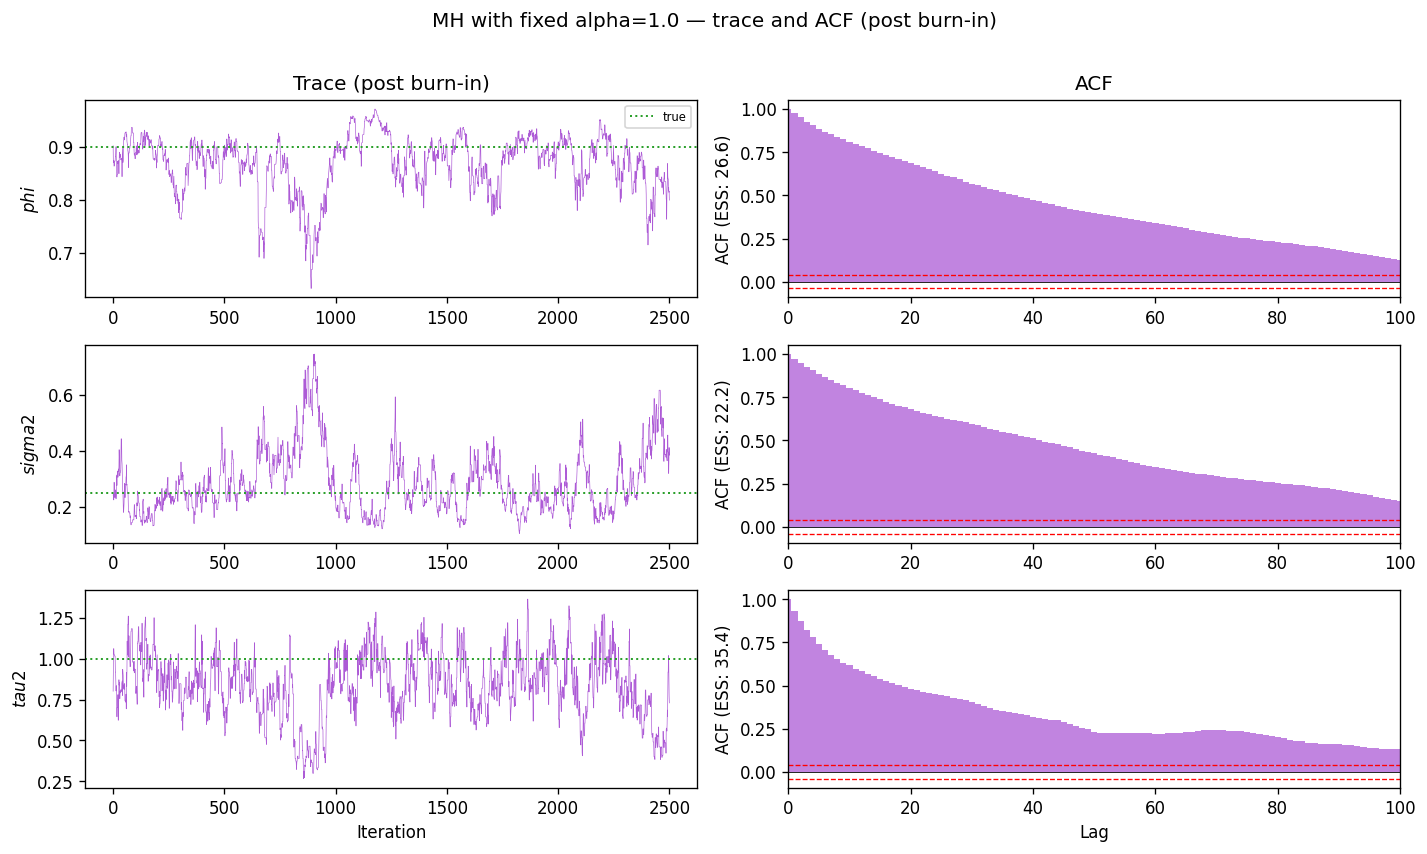

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='darkorchid', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2, label='true')
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s     = len(samp)
    max_lag = min(100, n_s - 1)
    xc      = samp - samp.mean()
    var     = xc.var()
    acf     = np.correlate(xc, xc, mode='full')[n_s - 1:] / (var * n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1],
             width=1.0, color='darkorchid', alpha=0.6)
    ax_a.axhline(0,  color='black', lw=0.5)
    ax_a.axhline( 1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.axhline(-1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.set_xlim(0, max_lag)
    ax_a.set_ylabel(f'ACF (ESS: {chain_ess(samp):.1f})') # Report ESS
    if k == 0:
        ax_a.set_title('ACF')

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Lag')
plt.suptitle('MH with fixed alpha=1.0 — trace and ACF (post burn-in)', y=1.01)
plt.tight_layout()
plt.show()


### 4. Parameter Estimation with Nelder-Mead

In [60]:
# Nelder-Mead PMMLE with alpha fixed — same 3-param model.
# Uses particle-filter log-likelihood estimate; expect ~3 min runtime.

from estimation.nelder_mead import NelderMeadPMMLE

model_nm = FixedAlphaSSM(
    alpha_fixed=alpha_true,
    phi=phi_true, sigma2=sigma2_true, tau2=tau2_true,
    initial_var=initial_var_fixed, seed=SEED,
)

nm = NelderMeadPMMLE(
    model=model_nm,
    data=observations,
    N_particles_1=100,
    N_particles_2=300,
    n_restarts=3,
    restart_std=0.5,
    seed=0,
)
nm_result = nm.fit()
print(nm_result.summary())


Stage 1  N_particles=100, 3 restart(s)
  restart 1/3: loglik≈-340.70  nfev=114  converged
  restart 2/3: loglik≈-343.01  nfev=103  converged
  restart 3/3: loglik≈-341.80  nfev=127  converged

Stage 2  N_particles=300, starting from stage-1 best
  loglik≈-341.56  nfev=152  converged
NelderMeadPMMLE.fit  111.893s
PMMResult  loglik=-341.6498
  Stage 1: converged  n_evals=344
  Stage 2: converged  n_evals=152
  Optimization terminated successfully.

  Parameter             Estimate
  --------------------------------
  phi                   0.898550
  sigma2                0.233822
  tau2                  1.000117


### 5. Comparison Summary of Parameter Estimation Methods

In [61]:
# Comparison: True | MLE | MH | NM PMMLE
# MLE SE:        delta-method standard errors in constrained space
# MH std (adj):  posterior std scaled by sqrt(n/ESS) to reflect MCMC autocorrelation

names_est = list(model_mle.params_dict.keys())   # ['phi', 'sigma2', 'tau2']
mle_con   = list(mle_result.constrained_params)
nm_con    = list(nm_result.constrained_params)

# MH posterior summaries (post-burn-in)
mh_mean, mh_adj_std = [], []
for k in range(len(names_est)):
    samp = constrained_fa[:, k]
    ess  = chain_ess(samp)
    mh_mean.append(samp.mean())
    mh_adj_std.append(samp.std() * np.sqrt(len(samp) / ess) if ess > 0 else np.nan)

# ── print table ───────────────────────────────────────────────────────────────
w = [10, 8, 10, 9, 10, 12, 10]
header = (
    f"{'Param':<{w[0]}} {'True':>{w[1]}} {'MLE':>{w[2]}} {'MLE SE':>{w[3]}}"
    f" {'MH mean':>{w[4]}} {'MH std(adj)':>{w[5]}} {'NM PMMLE':>{w[6]}}"
)
print(header)
print("─" * len(header))

for k, name in enumerate(names_est):
    tv = TRUE_PARAMS[name]
    se = (f"{mle_result.std_errors[k]:>{w[3]}.4f}"
          if mle_result.std_errors is not None and not np.isnan(mle_result.std_errors[k])
          else f"{'—':>{w[3]}}")
    print(
        f"{name:<{w[0]}} {tv:>{w[1]}.4f} {mle_con[k]:>{w[2]}.4f} {se}"
        f" {mh_mean[k]:>{w[4]}.4f} {mh_adj_std[k]:>{w[5]}.4f} {nm_con[k]:>{w[6]}.4f}"
    )

print()
print(f"{'Log-likelihood':<22} {'KF (exact)':>12} {'MLE':>12} {'—':>12} {'NM PMMLE (PF)':>14}")
print("─" * 64)
print(f"{'':22} {kf_loglik:>12.2f} {mle_result.loglik:>12.2f} {'—':>12} {nm_result.loglik:>14.2f}")

Param          True        MLE    MLE SE    MH mean  MH std(adj)   NM PMMLE
───────────────────────────────────────────────────────────────────────────
phi          0.9000     0.8857    0.0466     0.8689       0.5106     0.8986
sigma2       0.2500     0.2510    0.0861     0.2845       1.1797     0.2338
tau2         1.0000     0.8651    0.1806     0.8377       1.6374     1.0001

Log-likelihood           KF (exact)          MLE            —  NM PMMLE (PF)
────────────────────────────────────────────────────────────────
                            -341.78      -341.28            —        -341.65


## Section IV. Estimation Extension MH
1. Effect of number of iterations for MH (check for convergence to true or MLE values)
2. Misspecified fixed alpha for MH (compared with MLE with misspecified alpha as well)
3. Hypothesis testing on estimated parameters. 

## Section V: Estimation Extension PMMH and BlockedPMMH
Parameter estimation using PMMH, alpha fixed to true value
N_particles = 1000
Iterations = 1000
Choose burn-in period
Results: estimated parameter values
Plot Chain, ACF

In [55]:
# ── setup: naive PMMH and Block PMMH, both with alpha fixed ──────────────────
# Block structure: dynamics (phi=0) and noise variances (sigma2=1, tau2=2).
BLOCKS      = [[0], [1, 2]]   # dynamics block, noise variance block
N_ITER_CMP  = 2000
N_PART_CMP  = 500
BURN_IN_CMP = 500

model_n = FixedAlphaSSM(alpha_fixed = alpha_true, phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=1)
model_b = FixedAlphaSSM(alpha_fixed = alpha_true, phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=2)

theta0_cmp = model_n.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
)
step_cmp = np.array([0.10, 0.15, 0.15])   # per-dim steps: (atanh φ, log σ², log τ²)

pf_n   = ParticleFilter(model_n, N_PART_CMP, observations, SystematicResampling(seed=1))
pmmh_n = PMMH(model_n, pf_n, n_iter=N_ITER_CMP,
              step_sizes=step_cmp, theta0=theta0_cmp,
              log_prior=log_prior_fixed_alpha, seed=10)

pf_b   = ParticleFilter(model_b, N_PART_CMP, observations, SystematicResampling(seed=2))
pmmh_b = BlockPMMH(model_b, pf_b, n_iter=N_ITER_CMP,
                   step_sizes=step_cmp, theta0=theta0_cmp,
                   log_prior=log_prior_fixed_alpha,
                   blocks=BLOCKS, seed=20)

print(repr(pmmh_n))
print(repr(pmmh_b))

PMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=500)
BlockPMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=500, n_blocks=2)


In [56]:
print("Running naive PMMH (alpha fixed=1.0) ...")
chain_n, ll_n, acc_n = pmmh_n.run()
print(f"  acceptance rate: {acc_n.mean():.3f}")

Running naive PMMH (alpha fixed=1.0) ...


KeyboardInterrupt: 

In [ ]:
print("Running Block PMMH (alpha fixed=1.0) ...")
chain_b, ll_b, acc_b = pmmh_b.run()
print(f"  acceptance rate: {acc_b.mean():.3f}")

In [ ]:
constrained_n = model_n.constrain_chain(chain_n[BURN_IN_CMP:])
constrained_b = model_b.constrain_chain(chain_b[BURN_IN_CMP:])

In [ ]:
names_cmp = list(model_n.params_dict.keys())
print(f"\n{'':8}  {'True':>8}  {'Naive mean':>12} {'Naive ESS':>8} {'Block mean':>12} {'Block ESS':>8}")
print("─" * 46)
for k, name in enumerate(names_cmp):
    naive_ess = chain_ess(constrained_n[:, k])
    block_ess = chain_ess(constrained_b[:,k])
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{constrained_n[:, k].mean():>12.4f}  "
          f"{naive_ess:>12.4f}  "
          f"{constrained_b[:, k].mean():>12.4f}  "
          f"{block_ess:>12.4f}")

Past run results for reference:
```text
Running naive PMMH (alpha fixed=1.0) ...
[500/2000]  theta = [ 0.27135977 -0.15864891 -0.055782  ],  loglik = -496.14,  accept rate = 0.366
[1000/2000]  theta = [ 0.57457657 -0.41391876 -0.07222563],  loglik = -497.18,  accept rate = 0.365
[1500/2000]  theta = [ 0.89810643 -0.69848276 -0.07483479],  loglik = -494.56,  accept rate = 0.362
PMMH.run  2076.222s
  acceptance rate: 0.361
Running Block PMMH (alpha fixed=1.0) ...
BlockPMMH.run  4392.526s
  acceptance rate: 0.667

              True    Naive mean    Block mean
──────────────────────────────────────────────
phi         0.9000        0.8284        0.8487
sigma2      0.2500        0.3965        0.3473
tau2        1.0000        0.9474        0.9851
```

In [ ]:
# ── trace plots and posterior comparison ──────────────────────────────────────
names_cmp = list(model_n.params_dict.keys())
fig, axes = plt.subplots(3, 3, figsize=(13, 8))

for k, name in enumerate(names_cmp):
    tv = TRUE_PARAMS[name]

    for col, (label, ch, color) in enumerate([
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]):
        ax = axes[k, col]
        ax.plot(ch[:, k], lw=0.5, color=color, alpha=0.7)
        ax.axhline(tv, color='C2', ls=':', lw=1.2, label='true' if k == 0 else None)
        ax.set_ylabel(f'${name}$' if col == 0 else '')
        if k == 0:
            ax.set_title(label)
            ax.legend(fontsize=7)

    ax_m = axes[k, 2]
    lo = min(constrained_n[:, k].min(), constrained_b[:, k].min())
    hi = max(constrained_n[:, k].max(), constrained_b[:, k].max())
    bins = np.linspace(lo, hi, 40)
    for label, ch, color in [
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]:
        ax_m.hist(ch[:, k], bins=bins, density=True, alpha=0.4, color=color, label=label)
    ax_m.axvline(tv, color='C2', ls=':', lw=1.5)
    ax_m.set_xlabel(f'${name}$')
    if k == 0:
        ax_m.set_title('Posterior marginals')
        ax_m.legend(fontsize=7)

for col in range(2):
    axes[-1, col].set_xlabel('iteration (post burn-in)')
plt.suptitle(
    f'Naive PMMH (acc={acc_n.mean():.2f}) vs Block PMMH (acc={acc_b.mean():.2f})'
    r' — $\alpha$ fixed',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


## Section VI: Macro Regime Switching Model

### Regime-Switching Macro State-Space Model

A $K$-regime Markov-switching linear Gaussian SSM for four observed macro series. The discrete regime $s_t \in \{0, 1, \ldots, K-1\}$ captures structural shifts in volatility (e.g. expansion vs. recession). The continuous latent state evolves linearly conditional on $s_t$, so the full state is $(z_t, s_t)$.

**Latent state** $z_t = [x_t,\; g_t^*,\; u_t^*,\; \pi_t^e,\; r_t^*,\; x_{t-1}]^\top \in \mathbb{R}^6$

| Component | Interpretation |
|---|---|
| $x_t$ | Output gap |
| $g_t^*$ | Potential GDP growth |
| $u_t^*$ | Natural unemployment rate |
| $\pi_t^e$ | Expected inflation |
| $r_t^*$ | Neutral real interest rate |
| $x_{t-1}$ | Lagged output gap (state augmentation) |

**Regime transition** (first-order Markov):

$$P(s_t = j \mid s_{t-1} = i) = \text{softmax}(\mathbf{a}_i)_j, \qquad \mathbf{a}_i \in \mathbb{R}^K$$

**State transition** (shared $A$ and intercept $\mathbf{a}$, regime-specific noise):

$$z_t = A\, z_{t-1} + \mathbf{a} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\, Q_{s_t})$$

$$A = \begin{bmatrix} \rho_x & 0 & 0 & 0 & -\lambda_r & 0 \\ 0 & \rho_g & 0 & 0 & 0 & 0 \\ 0 & 0 & \rho_u & 0 & 0 & 0 \\ 0 & 0 & 0 & \rho_\pi & 0 & 0 \\ 0 & 0 & 0 & 0 & \rho_r & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix}, \qquad Q_{s_t} = \operatorname{diag}(\sigma_{s_t}^2, \mathbf{0})$$

The first row encodes the **IS curve**: $x_t = \rho_x x_{t-1} - \lambda_r r_{t-1}^* + \varepsilon_{x,t}$. Regime-switching enters only through $Q_{s_t}$: recession raises process volatility while the structural matrices $A$ and $H$ remain constant.

**Observations** $y_t = [\Delta Y_t,\; u_t,\; \pi_t,\; i_t]^\top \in \mathbb{R}^4$:

$$y_t = H\, z_t + \mathbf{b}_t + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, R)$$

The rows of $H$ encode three structural relationships and a monetary policy rule:

| Row | Equation | Model |
|---|---|---|
| $\Delta Y_t$ | GDP growth | $g_t^* + x_t - x_{t-1}$ |
| $u_t$ | Okun's law | $u_t^* - \beta_u x_t$ |
| $\pi_t$ | Phillips curve | $\pi_t^e + \kappa x_t$ |
| $i_t$ | Taylor rule | $\rho_i i_{t-1} + (1-\rho_i)(\phi_\pi \pi_t + \phi_x x_t + r_t^*)$ |

The interest-rate row introduces a time-varying intercept $\mathbf{b}_t = [0,\, 0,\, 0,\, \rho_i i_{t-1} - (1-\rho_i)\phi_\pi \pi^*]^\top$ that depends on the lagged nominal rate.

**Filtering:** the mixed discrete-continuous state $(z_t, s_t)$ rules out the standard Kalman filter. We compare two approaches: the **bootstrap particle filter** (PF), which samples both $z_t$ and $s_t$ jointly, and the **Rao-Blackwellized particle filter** (RBPF), which samples only $s_t$ and marginalises $z_t$ analytically via a per-particle Kalman filter, yielding lower variance at the same particle count.


1. Generate synthetic data
2. Show regime detection in rbpf filtering vs particle filter

In [ ]:
from models.regime_switching_macro import (
    RegimeSwitchingMacro, MacroParams, ModelDims, RegimeStructure
)
from estimation.rbpf import RaoBlackwellizedParticleFilter

# ── Model parameters ──────────────────────────────────────────────────────────
# 2-regime model: Regime 0 = expansion (low vol), Regime 1 = recession (high vol)
K_REGIMES  = 2
T_MACRO    = 200
SEED_MACRO = 0

true_macro_params = MacroParams(
    # Latent-state AR persistence
    rho_x=0.75, rho_g=0.95, rho_u=0.90, rho_pi=0.80, rho_r=0.85,

    # Long-run means (annualised %)
    g_bar=2.0, u_bar=5.0, pi_bar=2.0, r_bar=1.0,

    # Structural slopes
    lambda_r=0.50,   # IS curve: rate sensitivity of output gap
    beta_u=0.50,     # Okun's law
    kappa=0.05,      # Phillips curve (empirically flat)

    # Taylor rule
    rho_i=0.70, phi_pi=1.50, phi_x=0.50, pi_target=2.0,

    # Regime-specific state shock std devs  shape (K, 5): [x, g*, u*, π^e, r*]
    state_sigmas=np.array([
        [0.30, 0.10, 0.10, 0.20, 0.15],   # Regime 0: expansion
        [1.20, 0.30, 0.30, 0.50, 0.40],   # Regime 1: recession (~4× more volatile)
    ]),

    # Measurement noise std devs  shape (4,): [GDP growth, unemployment, π, rate]
    obs_sigmas=np.array([0.20, 0.20, 0.15, 0.10]),

    # Transition intercepts → softmax gives ~90% within-regime persistence
    trans_intercepts=np.array([[1.1, -1.1], [-1.1, 1.1]]),

    # Initial state: centred at long-run means  [x, g*, u*, π^e, r*, x_{-1}]
    init_state_mean=np.array([0.0, 2.0, 5.0, 2.0, 1.0, 0.0]),
    init_state_cov=np.diag([1.0, 0.5, 0.5, 0.5, 0.3, 1.0]),
)

macro_model = RegimeSwitchingMacro(
    params=true_macro_params,
    dims=ModelDims(n_regimes=K_REGIMES),
    structure=RegimeStructure(regime_specific_q=True),
    seed=SEED_MACRO,
)
print(macro_model.describe())

# ── Generate synthetic data ───────────────────────────────────────────────────
macro_states, macro_obs, macro_regimes, macro_true_loglik = macro_model.generate_data(T_MACRO)

regime_counts = np.bincount(macro_regimes, minlength=K_REGIMES)
print(f"\nRegime counts:  "
      f"Expansion={regime_counts[0]} ({100*regime_counts[0]/T_MACRO:.0f}%)  "
      f"Recession={regime_counts[1]} ({100*regime_counts[1]/T_MACRO:.0f}%)")
print(f"Conditional log-likelihood log p(y | z, s, θ): {macro_true_loglik:.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
def recession_spans(regimes, target=1):
    """Find contiguous runs of `target` regime; return list of (start, end) pairs."""
    spans, in_span = [], False
    for t, r in enumerate(regimes):
        if r == target and not in_span:
            start, in_span = t, True
        elif r != target and in_span:
            spans.append((start, t)); in_span = False
    if in_span:
        spans.append((start, len(regimes)))
    return spans

rec_spans = recession_spans(macro_regimes)
t_plot    = np.arange(T_MACRO)

obs_labels   = ['GDP growth (%)', 'Unemployment (%)', 'Inflation (%)', 'Nominal rate (%)']
obs_colors   = ['steelblue', 'coral', 'seagreen', 'darkorchid']

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
axes = axes.ravel()

for k, (label, color) in enumerate(zip(obs_labels, obs_colors)):
    axes[k].plot(t_plot, macro_obs[:, k], lw=0.8, color=color, label=label)
    axes[k].set_ylabel(label, fontsize=8)
    axes[k].legend(fontsize=7, loc='upper right')

axes[4].plot(t_plot, macro_states[:, 0], lw=0.9, color='black', label='Output gap $x_t$')
axes[4].axhline(0, color='grey', lw=0.6, ls='--')
axes[4].set_ylabel('Output gap', fontsize=8)
axes[4].legend(fontsize=7)

axes[5].step(t_plot, macro_regimes, lw=1.2, color='tomato')
axes[5].set_yticks([0, 1])
axes[5].set_yticklabels(['Expansion', 'Recession'], fontsize=8)
axes[5].set_ylabel('True regime', fontsize=8)

for ax in axes:
    for s, e in rec_spans:
        ax.axvspan(s, e, alpha=0.12, color='tomato', lw=0)

for ax in axes[-2:]:
    ax.set_xlabel('$t$ (quarters)')

fig.suptitle(
    f'Regime-Switching Macro Model — Synthetic Data  '
    f'(T={T_MACRO}, K={K_REGIMES} regimes)',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

## Section VIII: Macro Regime Switching Model Filtering using RBPF under true parameters

## Section IX: Macro Regime Switching Model Parameter Estimation using RBPF-PMMH

## Section IX: Other Extensions
1. Model misspecification: Gaussian estimator on data generated by t model
2. Model misspecification: Gaussian estimatior on data generated by ARMA model